3D Helmholtz Equation - Finite Difference Method Solver

Problem Parameters:
  Domain: ((-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0))
  Grid points: 21 × 21 × 21 = 9261
  Grid spacing: Δx = 0.1000
  Wave number k²: 1+0j

Solving 3D Helmholtz equation...
Solving linear system of size 9261×9261...
Note: Solution is complex. Max |Im(u)| = 0.00e+00
Imaginary part is negligible; using real part.
  Solution range (Re): [-0.5300, 0.0000]

Evaluation Metrics (on grid):
----------------------------------------
  MSE            : 7.067450e-07
  RMSE           : 8.406813e-04
  MAE            : 6.614504e-04
  MAX_ERROR      : 1.906461e-03
  RELATIVE_L2    : 3.924213e-03

Generating visualization slices...


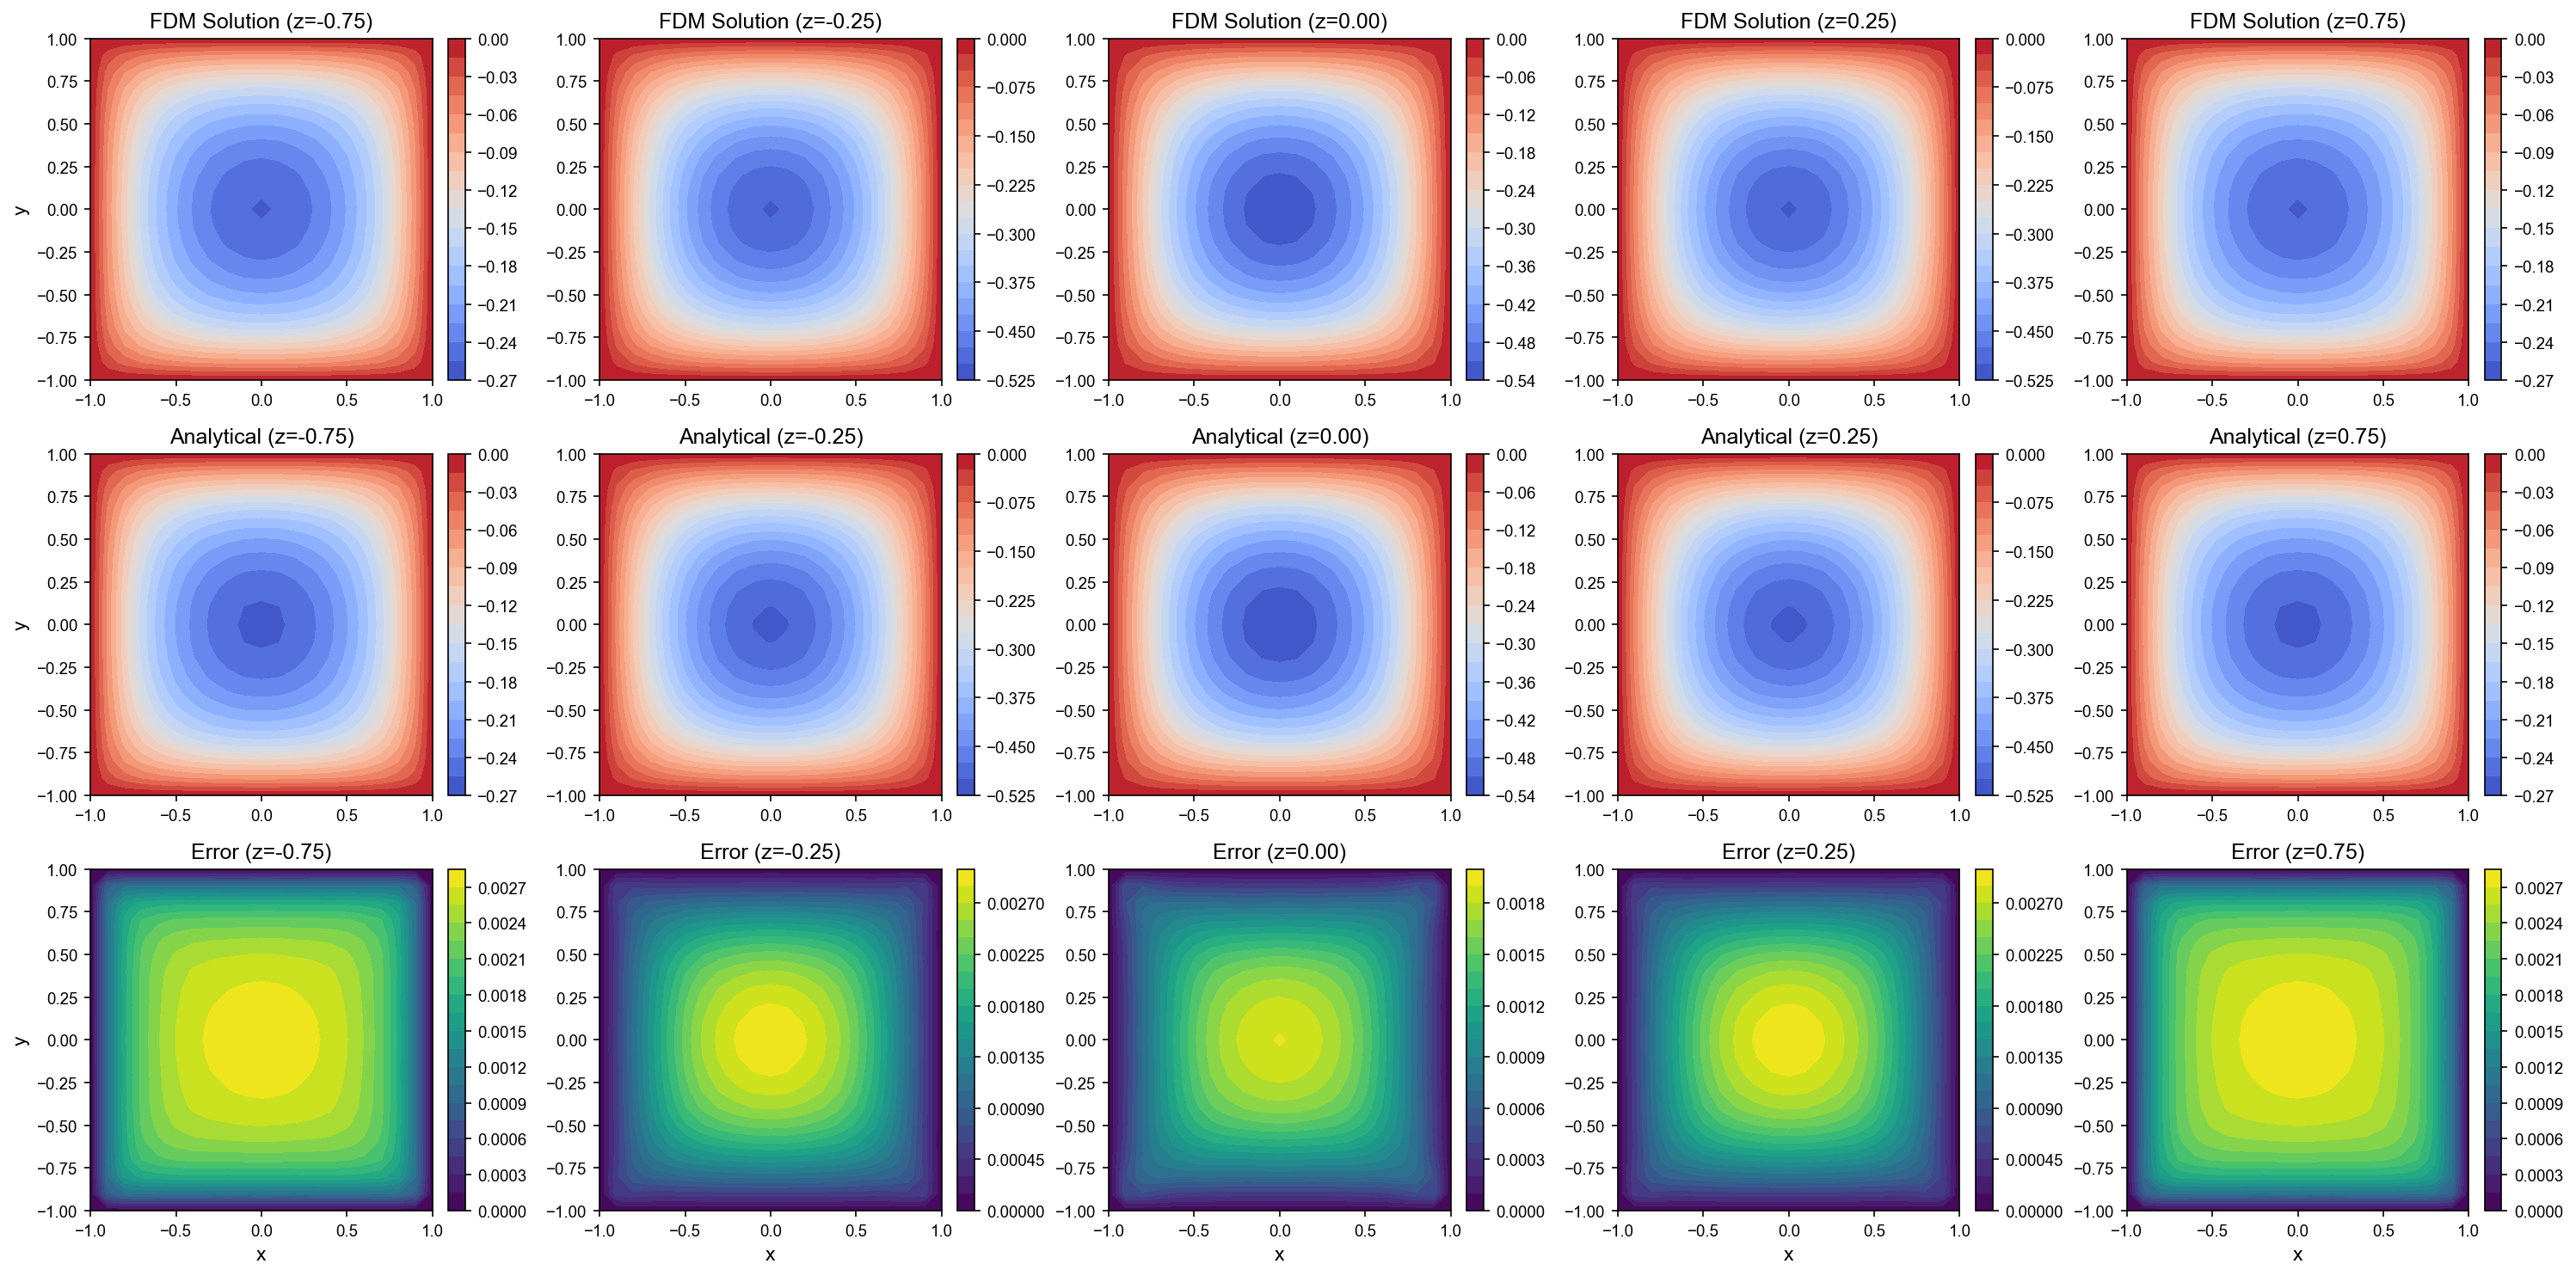


Performing convergence study...

Testing grid: 11 × 11 × 11
Solving linear system of size 1331×1331...
Note: Solution is complex. Max |Im(u)| = 0.00e+00
Imaginary part is negligible; using real part.

Testing grid: 15 × 15 × 15
Solving linear system of size 3375×3375...
Note: Solution is complex. Max |Im(u)| = 0.00e+00
Imaginary part is negligible; using real part.

Testing grid: 21 × 21 × 21
Solving linear system of size 9261×9261...
Note: Solution is complex. Max |Im(u)| = 0.00e+00
Imaginary part is negligible; using real part.

Testing grid: 25 × 25 × 25
Solving linear system of size 15625×15625...
Note: Solution is complex. Max |Im(u)| = 0.00e+00
Imaginary part is negligible; using real part.


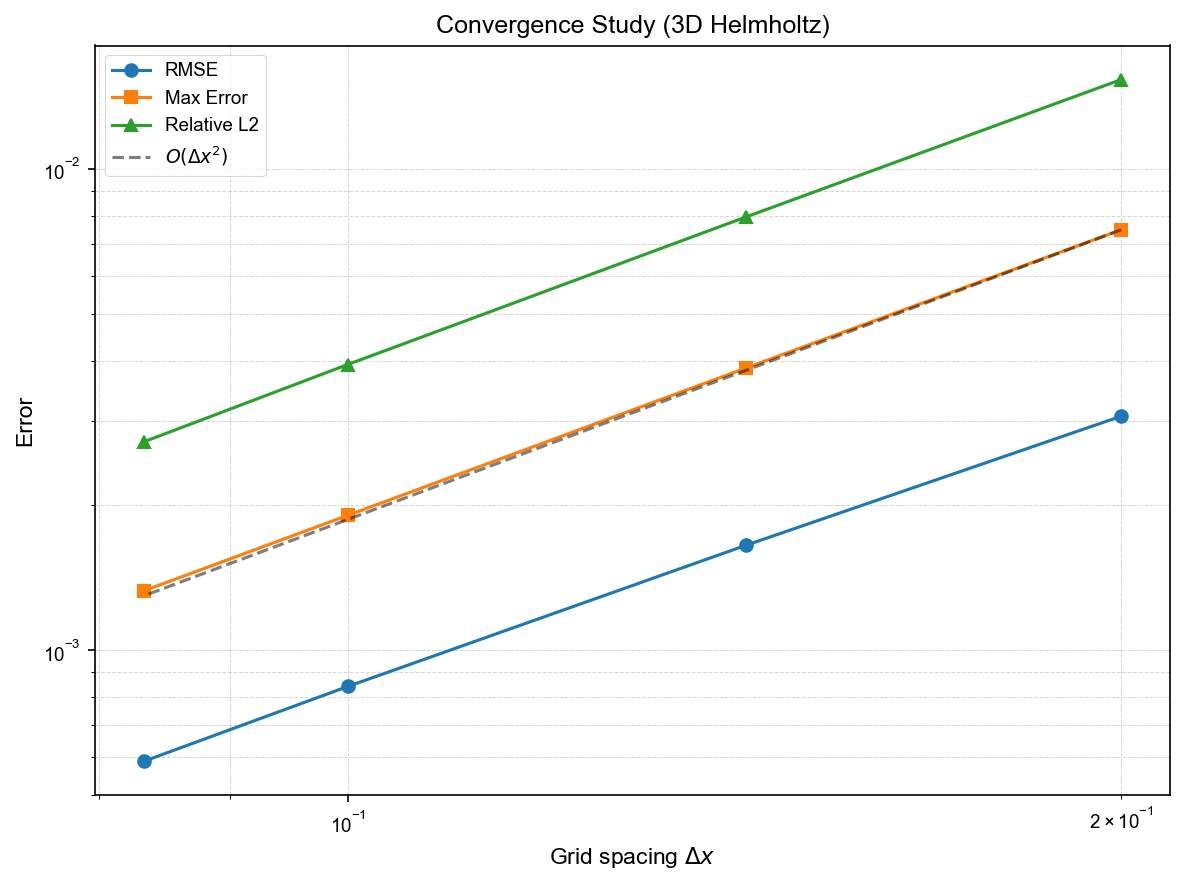


Convergence Results:
      Grid Size           Δx           RMSE      Max Error
----------------------------------------------------------------------
  11×11  ×11        0.20000   3.064179e-03   7.478064e-03
  15×15  ×15        0.14286   1.651597e-03   3.857966e-03
  21×21  ×21        0.10000   8.406813e-04   1.906461e-03
  25×25  ×25        0.08333   5.881758e-04   1.329732e-03

Estimated convergence rate: 1.97 (theoretical: 2.00)



In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm, gridspec, patches
from typing import Dict, List, Tuple, Optional, Callable, Union
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.interpolate import RegularGridInterpolator

plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
})
plt.rcParams['text.usetex'] = False

cmap_diverging = 'coolwarm'  # for solution
cmap_uncertainty = 'viridis'  # for error/uncertainty

class HelmholtzFDMSolver3D:
    r"""
    Finite Difference Method solver for 3D inhomogeneous Helmholtz equation

        (∇² + k²) u(x, y, z) = f(x, y, z)    on [a,b] × [c,d] × [e,f]

    with Dirichlet boundary conditions:

        u(x, y, z) = g(x, y, z)              on ∂Ω

    By default, this class sets up a mathematically consistent benchmark problem:

    - Domain:      [-1,1] × [-1,1] × [-1,1]
    - Analytic u:  sine–sine–sine eigenfunction that vanishes on the boundary
    - Source f:    chosen so that the analytic u satisfies (∇² + k²)u = f
    - BC g:        equal to the analytic u on the boundary (zero)
    """

    def __init__(
        self,
        domain: Tuple[Tuple[float, float], Tuple[float, float], Tuple[float, float]] = ((-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)),
        n_points: Tuple[int, int, int] = (21, 21, 21),
        source_func: Optional[Callable[[np.ndarray, np.ndarray, np.ndarray], np.ndarray]] = None,
        analytical_solution: Optional[Callable[[np.ndarray, np.ndarray, np.ndarray], np.ndarray]] = None,
        G_prime: float = 1.0,
        G_double_prime: float = 0.0,
        rho: float = 1.0,
        omega: float = 1.0,
        mode_numbers: Tuple[int, int, int] = (1, 1, 1),
        use_analytical_bc: bool = True,
    ):
        """
        Initialize the 3D FDM solver.

        Args
        ----
        domain:
            Computational domain ((x_min, x_max), (y_min, y_max), (z_min, z_max)).
        n_points:
            Number of grid points (n_x, n_y, n_z).
        source_func:
            Source term function f(x,y,z) taking meshgrid arrays (X, Y, Z).
        analytical_solution:
            Analytical solution u(x,y,z) for comparison and BC.
        G_prime:
            Storage modulus.
        G_double_prime:
            Loss modulus.
        rho:
            Density.
        omega:
            Angular frequency.
        mode_numbers:
            Tuple (m, n, p) of positive integers for the default benchmark mode.
        use_analytical_bc:
            If True, enforce BC using analytical_solution. If False, u=0.
        """
        self.domain = domain
        self.n_points = n_points
        self.G_prime = G_prime
        self.G_double_prime = G_double_prime
        self.rho = rho
        self.omega = omega
        self.mode_m, self.mode_n, self.mode_p = mode_numbers
        self.use_analytical_bc = use_analytical_bc

        # Grid dimensions
        self.nx, self.ny, self.nz = n_points
        self.n_total = self.nx * self.ny * self.nz

        # Wave number k^2
        self.k_squared = self._compute_wave_number()

        # Precompute eigenvalue λ for the default mode
        self.lambda_eig = self._compute_mode_eigenvalue()

        # Analytical solution
        if analytical_solution is None:
            self.analytical_solution = self._default_analytical_solution
            default_analytic = True
        else:
            self.analytical_solution = analytical_solution
            default_analytic = False

        # Source function
        if source_func is None and default_analytic:
            self.source_func = self._default_source_func
        elif source_func is None and not default_analytic:
            raise ValueError(
                "If you provide a custom analytical_solution, "
                "you must also provide a consistent source_func."
            )
        else:
            self.source_func = source_func

        # Setup grid arrays
        self._setup_grid()

        # Solution placeholder
        self.u_solution: Optional[np.ndarray] = None

    # ------------------------------------------------------------------
    # Core problem definition
    # ------------------------------------------------------------------

    def _compute_wave_number(self) -> complex:
        return (self.rho * self.omega ** 2) / (self.G_prime + 1j * self.G_double_prime)

    def _compute_mode_eigenvalue(self) -> float:
        (a, b), (c, d), (e, f) = self.domain
        m, n, p = self.mode_m, self.mode_n, self.mode_p
        lam = (np.pi * m / (b - a)) ** 2 + \
              (np.pi * n / (d - c)) ** 2 + \
              (np.pi * p / (f - e)) ** 2
        return lam

    def _default_analytical_solution(self, X: np.ndarray, Y: np.ndarray, Z: np.ndarray) -> np.ndarray:
        (a, b), (c, d), (e, f) = self.domain
        m, n, p = self.mode_m, self.mode_n, self.mode_p

        xi = (X - a) / (b - a)
        eta = (Y - c) / (d - c)
        zeta = (Z - e) / (f - e)

        return np.sin(np.pi * m * xi) * np.sin(np.pi * n * eta) * np.sin(np.pi * p * zeta)

    def _default_source_func(self, X: np.ndarray, Y: np.ndarray, Z: np.ndarray) -> np.ndarray:
        u = self._default_analytical_solution(X, Y, Z)
        return (-self.lambda_eig + self.k_squared) * u

    # ------------------------------------------------------------------
    # Grid & index helpers
    # ------------------------------------------------------------------

    def _setup_grid(self) -> None:
        x_min, x_max = self.domain[0]
        y_min, y_max = self.domain[1]
        z_min, z_max = self.domain[2]

        self.x = np.linspace(x_min, x_max, self.nx)
        self.y = np.linspace(y_min, y_max, self.ny)
        self.z = np.linspace(z_min, z_max, self.nz)
        
        # indexing='ij' gives (nx, ny, nz)
        self.X, self.Y, self.Z = np.meshgrid(self.x, self.y, self.z, indexing="ij")

        self.dx = (x_max - x_min) / (self.nx - 1)
        self.dy = (y_max - y_min) / (self.ny - 1)
        self.dz = (z_max - z_min) / (self.nz - 1)

    def _get_index(self, i: int, j: int, k: int) -> int:
        """Convert 3D grid indices (i,j,k) to 1D linear index."""
        return i * (self.ny * self.nz) + j * self.nz + k

    def _is_boundary(self, i: int, j: int, k: int) -> bool:
        return (i == 0 or i == self.nx - 1 or 
                j == 0 or j == self.ny - 1 or 
                k == 0 or k == self.nz - 1)

    # ------------------------------------------------------------------
    # System assembly
    # ------------------------------------------------------------------

    def build_system(self) -> Tuple[csr_matrix, np.ndarray]:
        r"""
        Build the linear system A u = b for the 3D FDM discretization using a 7-point stencil.
        """
        n = self.n_total
        dx2 = self.dx ** 2
        dy2 = self.dy ** 2
        dz2 = self.dz ** 2

        f_grid = self.source_func(self.X, self.Y, self.Z)

        complex_problem = np.iscomplexobj(self.k_squared) or np.iscomplexobj(f_grid)
        dtype = complex if complex_problem else float

        A = lil_matrix((n, n), dtype=dtype)
        b = np.zeros(n, dtype=dtype)

        # Precompute coefficients
        inv_dx2 = 1.0 / dx2
        inv_dy2 = 1.0 / dy2
        inv_dz2 = 1.0 / dz2
        center_coeff = -2.0 * (inv_dx2 + inv_dy2 + inv_dz2) + self.k_squared

        for i in range(self.nx):
            for j in range(self.ny):
                for k in range(self.nz):
                    idx = self._get_index(i, j, k)

                    if self._is_boundary(i, j, k):
                        A[idx, idx] = 1.0
                        if self.use_analytical_bc and self.analytical_solution is not None:
                            u_bc = self.analytical_solution(
                                np.array([[[self.x[i]]]]), 
                                np.array([[[self.y[j]]]]),
                                np.array([[[self.z[k]]]])
                            )[0, 0, 0]
                            b[idx] = u_bc
                        else:
                            b[idx] = 0.0
                    else:
                        # Interior node: 7-point stencil
                        A[idx, idx] = center_coeff

                        # Neighbors
                        A[idx, self._get_index(i - 1, j, k)] = inv_dx2
                        A[idx, self._get_index(i + 1, j, k)] = inv_dx2
                        A[idx, self._get_index(i, j - 1, k)] = inv_dy2
                        A[idx, self._get_index(i, j + 1, k)] = inv_dy2
                        A[idx, self._get_index(i, j, k - 1)] = inv_dz2
                        A[idx, self._get_index(i, j, k + 1)] = inv_dz2

                        b[idx] = f_grid[i, j, k]

        return A.tocsr(), b

    # ------------------------------------------------------------------
    # Solving & prediction
    # ------------------------------------------------------------------

    def solve(self) -> np.ndarray:
        A, b = self.build_system()

        print(f"Solving linear system of size {self.n_total}×{self.n_total}...")
        u_flat = spsolve(A, b)
        self.u_solution = u_flat.reshape((self.nx, self.ny, self.nz))

        if np.iscomplexobj(self.u_solution):
            max_imag = np.max(np.abs(np.imag(self.u_solution)))
            print(f"Note: Solution is complex. Max |Im(u)| = {max_imag:.2e}")
            if max_imag < 1e-12:
                print("Imaginary part is negligible; using real part.")
                self.u_solution = np.real(self.u_solution)

        return self.u_solution

    def predict(self, X_test: np.ndarray, Y_test: np.ndarray, Z_test: np.ndarray) -> np.ndarray:
        if self.u_solution is None:
            raise ValueError("Solution not computed yet.")

        # RegularGridInterpolator expects (x, y, z) points, not meshgrids directly
        # and data shape (nx, ny, nz)
        u_real = np.real(self.u_solution)
        interpolator = RegularGridInterpolator((self.x, self.y, self.z), u_real)

        # Flatten test points to (N, 3) array
        points = np.stack([X_test.flatten(), Y_test.flatten(), Z_test.flatten()], axis=1)
        u_pred_flat = interpolator(points)
        
        return u_pred_flat.reshape(X_test.shape)

    # ------------------------------------------------------------------
    # Metrics & plotting
    # ------------------------------------------------------------------

    def compute_metrics(
        self,
        X_test: Optional[np.ndarray] = None,
        Y_test: Optional[np.ndarray] = None,
        Z_test: Optional[np.ndarray] = None,
        metrics: Optional[List[str]] = None,
    ) -> Dict[str, float]:
        if self.u_solution is None:
            raise ValueError("Solution not computed yet.")

        if metrics is None:
            metrics = ["mse", "rmse", "mae", "max_error", "relative_l2"]

        if X_test is None or Y_test is None or Z_test is None:
            u_pred = self.u_solution.flatten()
            u_true = self.analytical_solution(self.X, self.Y, self.Z).flatten()
        else:
            u_pred = self.predict(X_test, Y_test, Z_test).flatten()
            u_true = self.analytical_solution(X_test, Y_test, Z_test).flatten()

        diff = u_true - u_pred

        results = {}
        if "mse" in metrics:
            results["mse"] = float(np.mean(np.abs(diff) ** 2))
        if "rmse" in metrics:
            results["rmse"] = float(np.sqrt(results.get("mse", np.mean(np.abs(diff) ** 2))))
        if "mae" in metrics:
            results["mae"] = float(np.mean(np.abs(diff)))
        if "max_error" in metrics:
            results["max_error"] = float(np.max(np.abs(diff)))
        if "relative_l2" in metrics:
            results["relative_l2"] = float(np.linalg.norm(diff) / np.linalg.norm(u_true))

        return results

    def plot_solution(self, z_values: List[float], save_path: Optional[str] = None, show_plot: bool = True):
        """
        Plot 2D slices of the 3D solution at specified z-values using interpolation.
        """
        if self.u_solution is None:
            raise ValueError("Solution not computed yet.")

        num_slices = len(z_values)
        if num_slices == 0:
            return

        # Setup figure: rows for Solution, Analytical, Error
        fig, axes = plt.subplots(3, num_slices, figsize=(4 * num_slices, 10), squeeze=False)
        
        # Create the X, Y mesh for the slices (fixed for all Z)
        X_slice, Y_slice = np.meshgrid(self.x, self.y, indexing='ij')

        for k, z_val in enumerate(z_values):
            # Create a Z-plane filled with the exact requested z_val
            Z_plane = np.full_like(X_slice, z_val)

            # 1. Get FDM Solution via Interpolation (uses self.predict)
            #    Note: self.predict returns real part automatically in your code
            sol_slice = self.predict(X_slice, Y_slice, Z_plane)

            # 2. Compute Analytical Solution at exact Z plane
            #    We must handle complex numbers if analytical solution returns them
            u_ana_complex = self.analytical_solution(X_slice, Y_slice, Z_plane)
            ana_slice = np.real(u_ana_complex)

            # 3. Compute Error
            err_slice = np.abs(sol_slice - ana_slice)

            # --- Plotting ---
            
            # Row 1: FDM Solution
            ax = axes[0, k]
            im1 = ax.contourf(X_slice, Y_slice, sol_slice, levels=20, cmap=cmap_diverging)
            ax.set_title(f"FDM Solution (z={z_val:.2f})")
            ax.set_aspect('equal')
            if k == 0: ax.set_ylabel("y")
            fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

            # Row 2: Analytical Solution
            ax = axes[1, k]
            im2 = ax.contourf(X_slice, Y_slice, ana_slice, levels=20, cmap=cmap_diverging)
            ax.set_title(f"Analytical (z={z_val:.2f})")
            ax.set_aspect('equal')
            if k == 0: ax.set_ylabel("y")
            fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

            # Row 3: Error
            ax = axes[2, k]
            im3 = ax.contourf(X_slice, Y_slice, err_slice, levels=20, cmap=cmap_uncertainty)
            ax.set_title(f"Error (z={z_val:.2f})")
            ax.set_aspect('equal')
            ax.set_xlabel("x")
            if k == 0: ax.set_ylabel("y")
            fig.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        
        if show_plot:
            plt.show()

    # ------------------------------------------------------------------
    # Convergence study
    # ------------------------------------------------------------------

    def convergence_study(self, n_points_list: Optional[List[Tuple[int, int, int]]] = None) -> Dict:
        if n_points_list is None:
            # Default 3D grids (keep them smaller than 2D due to N^3 scaling)
            n_points_list = [(11, 11, 11), (21, 21, 21), (31, 31, 31), (41, 41, 41)]

        results = {
            "n_points": [],
            "dx": [],
            "rmse": [],
            "max_error": [],
            "relative_l2": [],
        }

        original_n_points = self.n_points

        for n_x, n_y, n_z in n_points_list:
            print(f"\nTesting grid: {n_x} × {n_y} × {n_z}")

            self.n_points = (n_x, n_y, n_z)
            self.nx, self.ny, self.nz = n_x, n_y, n_z
            self.n_total = n_x * n_y * n_z
            self._setup_grid()

            self.solve()
            metrics = self.compute_metrics(metrics=["rmse", "max_error", "relative_l2"])

            results["n_points"].append((n_x, n_y, n_z))
            results["dx"].append(self.dx)
            results["rmse"].append(metrics["rmse"])
            results["max_error"].append(metrics["max_error"])
            results["relative_l2"].append(metrics["relative_l2"])

        # Restore
        self.n_points = original_n_points
        self.nx, self.ny, self.nz = original_n_points
        self.n_total = original_n_points[0] * original_n_points[1] * original_n_points[2]
        self._setup_grid()

        # Plot convergence
        fig, ax = plt.subplots(figsize=(8, 6))
        dx_array = np.array(results["dx"])

        ax.loglog(dx_array, results["rmse"], "o-", label="RMSE")
        ax.loglog(dx_array, results["max_error"], "s-", label="Max Error")
        ax.loglog(dx_array, results["relative_l2"], "^-", label="Relative L2")

        # Reference slope
        ref_line = results["max_error"][0] * (dx_array / dx_array[0]) ** 2
        ax.loglog(dx_array, ref_line, "k--", alpha=0.5, label="$O(\\Delta x^2)$")

        ax.set_xlabel("Grid spacing $\\Delta x$")
        ax.set_ylabel("Error")
        ax.set_title("Convergence Study (3D Helmholtz)")
        ax.legend()
        ax.grid(True, which="both", linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        return results

def analytical_constant_source_3d(X, Y, Z, k_squared=1.0, M=11, N=11, P=11):
    """
    Approximate analytic solution of (Δ + k^2) u = 3 on (-1,1)^3,
    u = 0 on the boundary, using a truncated sine series.
    """
    # Map to [0,1]
    xi  = (X + 1.0) / 2.0
    eta = (Y + 1.0) / 2.0
    zeta = (Z + 1.0) / 2.0

    dtype = complex if np.iscomplexobj(k_squared) else float
    u = np.zeros_like(X, dtype=dtype)

    # Expansion for constant source f=3 (or any constant C)
    # Coefficients are non-zero only for odd m,n,p
    # coeff ~ 1/(mnp * (-lam + k^2))
    
    # Constant term in expansion of f(x,y,z)=1 is 64/(pi^3 mnp) for odd m,n,p
    # Here we solve (Lap + k^2)u = C.
    # Let's just use the same logic: u = sum A_mnp phi_mnp
    # ( -lam_mnp + k^2 ) A_mnp = f_mnp
    # f_mnp = <f, phi_mnp> / <phi, phi>
    # If f=constant, f_mnp is non-zero for odd indices.
    
    # For f(x)=1 on [0,1], coeff is 4/(pi*n) for sin(n*pi*x)
    # So for f(x,y,z)=C, coeff is C * (4/pi)^3 * 1/(mnp)
    
    C = 2.0 # Arbitrary constant source strength
    
    for m in range(1, M, 2):
        for n in range(1, N, 2):
            for p in range(1, P, 2):
                lam = (np.pi*m/2)**2 + (np.pi*n/2)**2 + (np.pi*p/2)**2
                denom = -lam + k_squared
                
                # Fourier coeff for the source f=C
                f_coeff = C * (4.0/np.pi)**3 / (m*n*p)
                
                u_coeff = f_coeff / denom
                
                u += u_coeff * np.sin(np.pi*m*xi) * np.sin(np.pi*n*eta) * np.sin(np.pi*p*zeta)
    return u

def main():
    print("=" * 70)
    print("3D Helmholtz Equation - Finite Difference Method Solver")
    print("=" * 70)

    def const_source(X, Y, Z):
        return 2.0 * np.ones_like(X)

    # Initialize solver
    solver = HelmholtzFDMSolver3D(
        domain=((-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)),
        n_points=(21, 21, 21),
        source_func=const_source,
        analytical_solution=None,
        use_analytical_bc=False,
    )

    # Use the series solution for validation
    solver.analytical_solution = lambda X, Y, Z: analytical_constant_source_3d(
        X, Y, Z, k_squared=solver.k_squared, M=51, N=51, P=51
    )

    print("\nProblem Parameters:")
    print(f"  Domain: {solver.domain}")
    print(f"  Grid points: {solver.nx} × {solver.ny} × {solver.nz} = {solver.n_total}")
    print(f"  Grid spacing: Δx = {solver.dx:.4f}")
    print(f"  Wave number k²: {solver.k_squared:.6g}")

    print("\nSolving 3D Helmholtz equation...")
    u_fdm = solver.solve()
    print(f"  Solution range (Re): [{np.min(np.real(u_fdm)):.4f}, {np.max(np.real(u_fdm)):.4f}]")

    print("\nEvaluation Metrics (on grid):")
    print("-" * 40)
    metrics = solver.compute_metrics()
    for name, value in metrics.items():
        print(f"  {name.upper():15s}: {value:.6e}")

    print("\nGenerating visualization slices...")
    z_slices = [-0.75, -0.25, 0.0, 0.25, 0.75]
    solver.plot_solution(z_slices)

    print("\nPerforming convergence study...")
    # Use smaller grids for 3D convergence to save time in demo
    convergence_results = solver.convergence_study(n_points_list=[
        (11, 11, 11), (15, 15, 15), (21, 21, 21), (25, 25, 25)
    ])

    print("\n" + "=" * 70)
    print("Convergence Results:")
    print("=" * 70)
    print(f"{'Grid Size':>15} {'Δx':>12} {'RMSE':>14} {'Max Error':>14}")
    print("-" * 70)
    for (nx, ny, nz), dx, rmse, max_err in zip(
        convergence_results["n_points"],
        convergence_results["dx"],
        convergence_results["rmse"],
        convergence_results["max_error"],
    ):
        print(f"{nx:>4}×{ny:<4}×{nz:<4} "
              f"{dx:>12.5f} "
              f"{rmse:>14.6e} "
              f"{max_err:>14.6e}")

    if len(convergence_results["dx"]) > 1:
        log_dx = np.log(convergence_results["dx"])
        log_err = np.log(convergence_results["max_error"])
        rate = np.polyfit(log_dx, log_err, 1)[0]
        print(f"\nEstimated convergence rate: {rate:.2f} (theoretical: 2.00)")

    print("\n" + "=" * 70)

if __name__ == "__main__":
    main()